In [1]:
# basic packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import the dataset
df=pd.read_csv("college_student_placement_dataset.csv")
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


---

In [3]:
# null values
df.isnull().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [4]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [5]:
df.shape

(10000, 10)

---

In [6]:
# dataset
df[:5]

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [7]:
# reducing the dimensions
df.drop(columns=["College_ID","Prev_Sem_Result","Extra_Curricular_Score"],inplace=True)

In [8]:
# verify
df.shape

(10000, 7)

In [9]:
# dataset
df[:2]

,IQ,CGPA,Academic_Performance,Internship_Experience,Communication_Skills,Projects_Completed,Placement
0,107,6.28,8,No,8,4,No
1,97,5.37,8,No,8,0,No


---

In [10]:
# verify
df.isnull().sum()

IQ                       0
CGPA                     0
Academic_Performance     0
Internship_Experience    0
Communication_Skills     0
Projects_Completed       0
Placement                0
dtype: int64

In [11]:
# no nulls

In [12]:
# duplicates
df.duplicated().sum()

3

In [13]:
# drop duplicated
df.drop_duplicates(inplace=True)

In [14]:
# duplicates
df.duplicated().sum()

0

---

In [15]:
# dataset
df[:3]

,IQ,CGPA,Academic_Performance,Internship_Experience,Communication_Skills,Projects_Completed,Placement
0,107,6.28,8,No,8,4,No
1,97,5.37,8,No,8,0,No
2,109,5.83,9,No,1,1,No


In [16]:
# distribution of Internship_Experience
df.Internship_Experience.value_counts()

Internship_Experience
No     6035
Yes    3962
Name: count, dtype: int64

In [17]:
# distribution of Placment
df.Placement.value_counts()

Placement
No     8338
Yes    1659
Name: count, dtype: int64

In [18]:
df.Projects_Completed.value_counts()

Projects_Completed
5    1702
4    1693
0    1687
2    1681
3    1626
1    1608
Name: count, dtype: int64

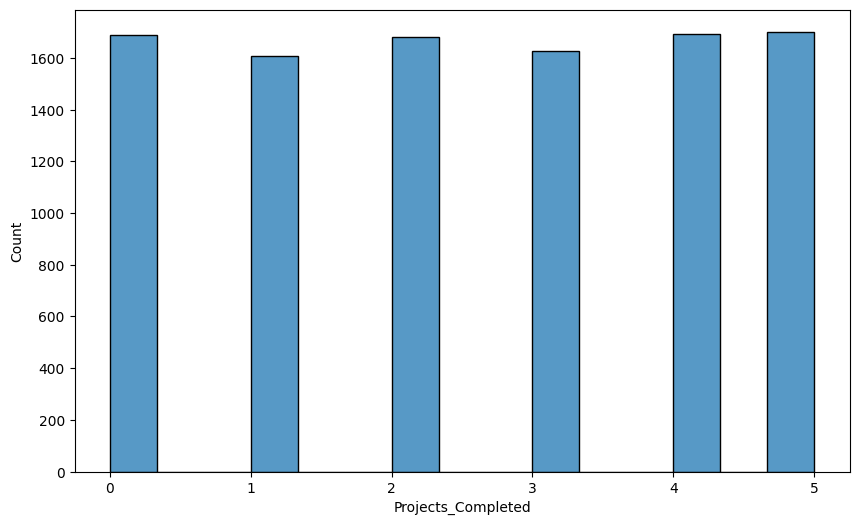

In [19]:
plt.figure(figsize=(10,6))
ax = sns.histplot(x="Projects_Completed", data=df, bins=15, kde=False)

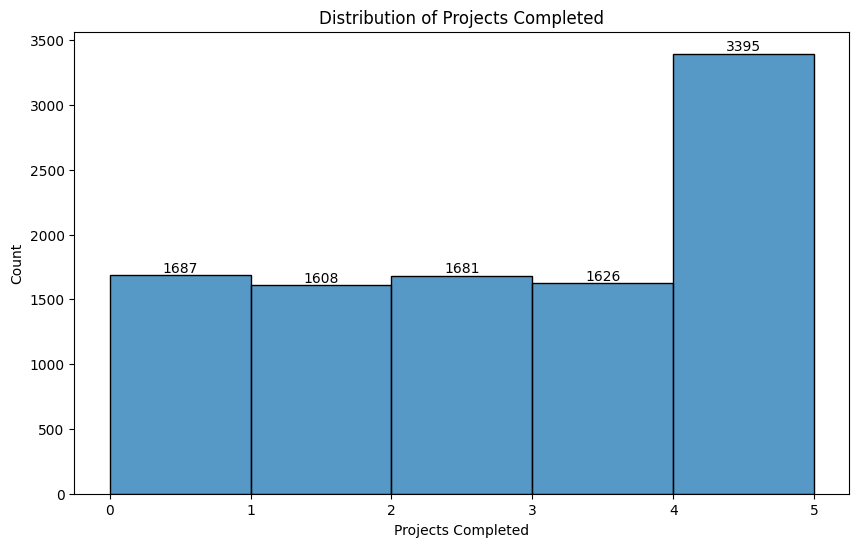

In [20]:
# distribution of Projects Completed

plt.figure(figsize=(10,6))

ax = sns.histplot(x="Projects_Completed", data=df, bins=5)

plt.title("Distribution of Projects Completed")
plt.xlabel("Projects Completed")
plt.ylabel("Count")

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height,
                int(height),
                ha='center', va='bottom')

plt.show()

In [21]:
df["CGPA_bin"] = pd.cut(df["CGPA"], bins=[0,6,7.5,10],
                       labels=["Low","Medium","High"])

In [22]:
df["Comm_bin"] = pd.cut(df["Communication_Skills"],
                       bins=[0,4,7,10],
                       labels=["Low","Medium","High"])

In [23]:
df["Projects_bin"] = pd.cut(df["Projects_Completed"],
                           bins=[-1,1,3,10],
                           labels=["Low","Medium","High"])

In [24]:
df[:2]

,IQ,CGPA,Academic_Performance,Internship_Experience,Communication_Skills,Projects_Completed,Placement,CGPA_bin,Comm_bin,Projects_bin
0,107,6.28,8,No,8,4,No,Medium,High,High
1,97,5.37,8,No,8,0,No,Low,High,Low


In [25]:
df.drop(["CGPA","Communication_Skills","Projects_Completed"], axis = 1, inplace = True)

In [26]:
df[:2]

,IQ,Academic_Performance,Internship_Experience,Placement,CGPA_bin,Comm_bin,Projects_bin
0,107,8,No,No,Medium,High,High
1,97,8,No,No,Low,High,Low


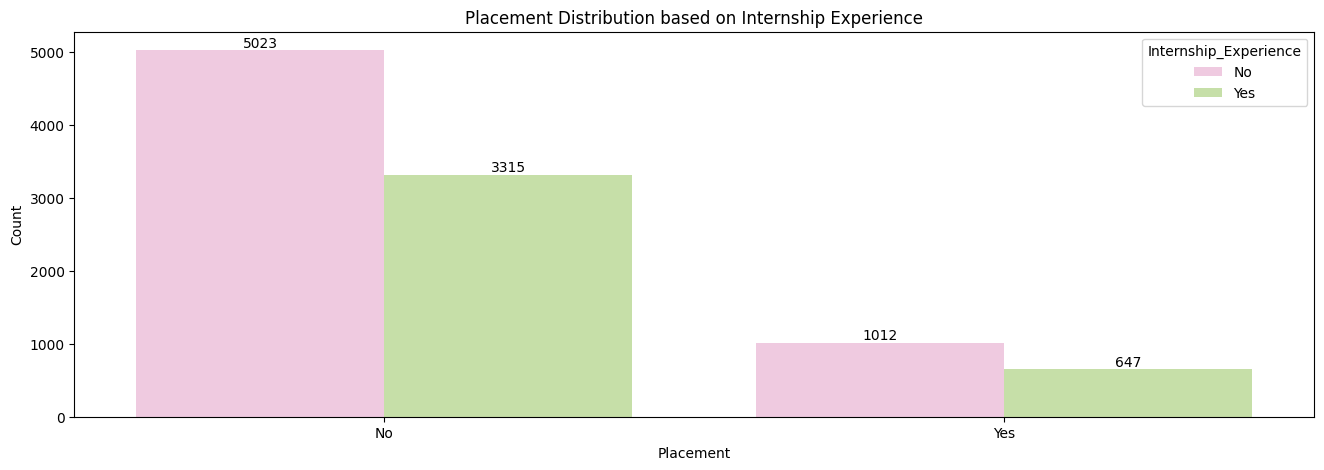

In [27]:

plt.figure(figsize=(16, 5))

a = sns.countplot(
    data=df,
    x="Placement",
    hue="Internship_Experience",
    palette="PiYG"
)

# Add labels on bars
for container in a.containers:
    a.bar_label(container)

plt.title("Placement Distribution based on Internship Experience")
plt.xlabel("Placement")
plt.ylabel("Count")

plt.show()

---

In [28]:
# dataset
df[:1]

,IQ,Academic_Performance,Internship_Experience,Placement,CGPA_bin,Comm_bin,Projects_bin
0,107,8,No,No,Medium,High,High


In [29]:
# view data
df.head()

,IQ,Academic_Performance,Internship_Experience,Placement,CGPA_bin,Comm_bin,Projects_bin
0,107,8,No,No,Medium,High,High
1,97,8,No,No,Low,High,Low
2,109,9,No,No,Low,Low,Low
3,122,6,Yes,No,Low,Medium,Low
4,96,7,No,No,High,High,Medium


In [30]:
df.to_csv("cspd_cleaned.csv" , index = False)